         CustomerID      Recency    Frequency       Monetary  AvgOrderValue  \
count   3920.000000  3920.000000  3920.000000    3920.000000    3920.000000   
mean   15562.059694    91.742092     4.246429    1864.385601     393.327827   
std     1576.594671    99.533485     7.199202    7482.817477    1869.970792   
min    12346.000000     0.000000     1.000000       3.750000       3.450000   
25%    14208.750000    17.000000     1.000000     300.280000     174.396875   
50%    15569.500000    50.000000     2.000000     652.280000     281.617500   
75%    16913.250000   142.000000     5.000000    1576.585000     409.693000   
max    18287.000000   373.000000   209.000000  259657.300000   84236.250000   

       UniqueProducts   AvgQuantity   DaysActive  OrdersPerDay      Churned  
count     3920.000000   3920.000000  3920.000000   3920.000000  3920.000000  
mean        60.726531     47.809740   131.021173      0.413487     0.333418  
std         81.670816   1265.867626   132.271348      

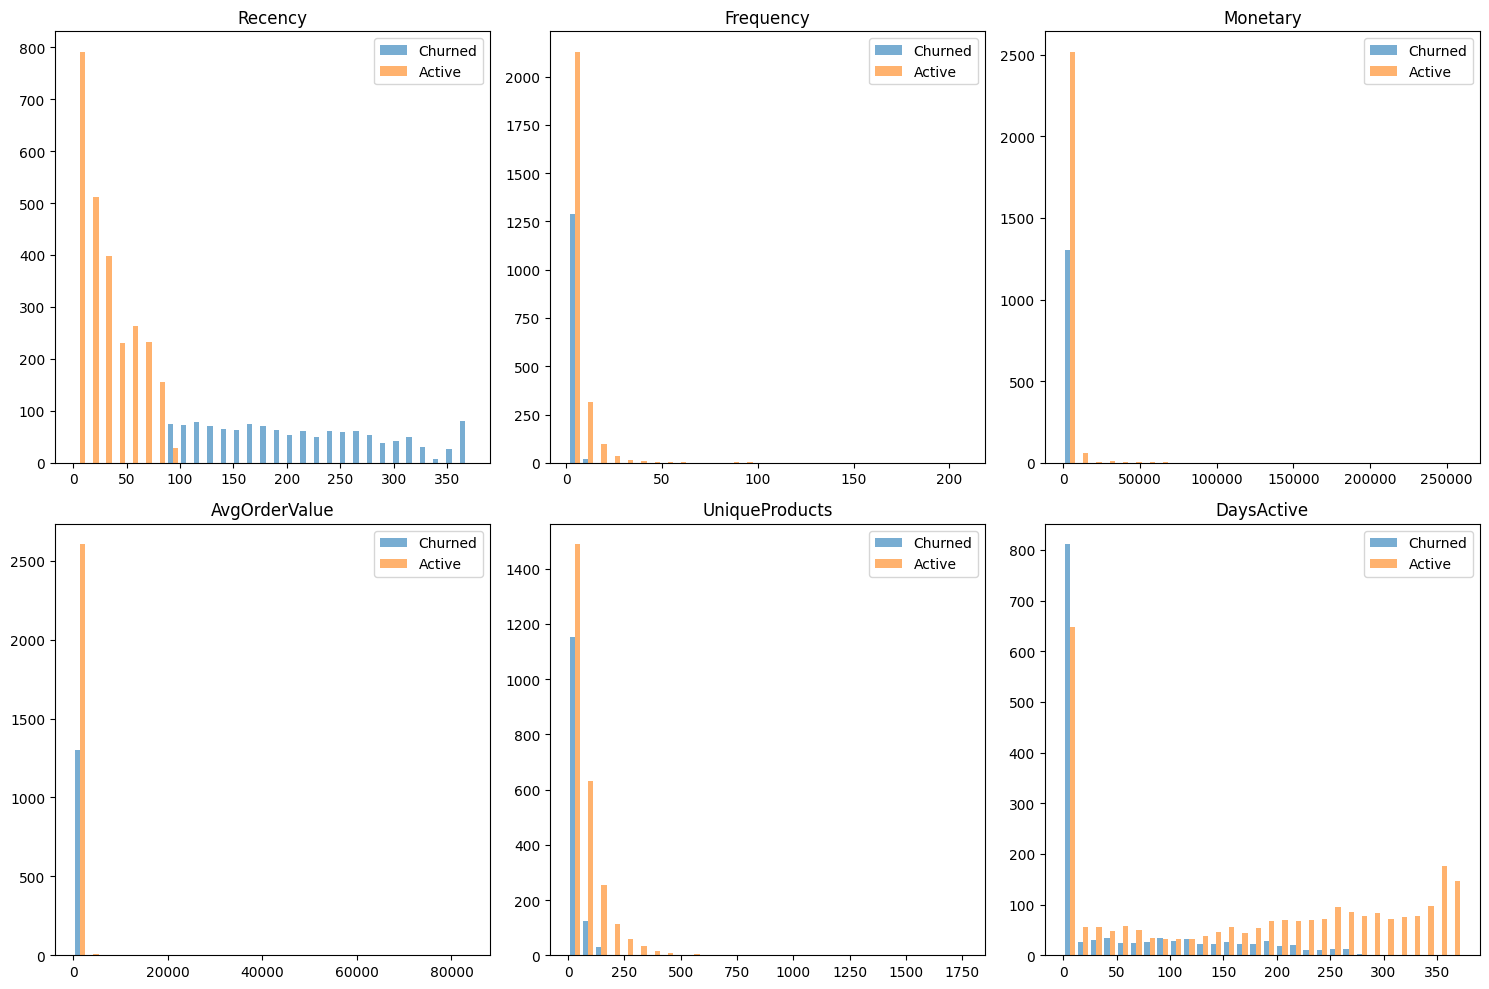

✅ Feature distributions plotted


In [11]:
import pandas as pd
import matplotlib.pyplot as plt

customers = pd.read_csv('../data/processed/customer_features.csv')

print(customers.describe())
print(f"\nChurn rate: {customers['Churned'].mean():.1%}")

# Plot churn distribution
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

features = ['Recency', 'Frequency', 'Monetary', 'AvgOrderValue', 'UniqueProducts', 'DaysActive']

for ax, feature in zip(axes.flatten(), features):
    churned = customers[customers['Churned']==1][feature]
    active = customers[customers['Churned']==0][feature]
    ax.hist([churned, active], bins=30, label=['Churned', 'Active'], alpha=0.6)
    ax.set_title(feature)
    ax.legend()

plt.tight_layout()
plt.savefig('customer_feature_distributions.png')
plt.show()
print("✅ Feature distributions plotted")


In [12]:
# Investigate negative Recency
negative_recency = customers[customers['Recency'] < 0]
print(f"Customers with negative Recency: {len(negative_recency)}")
print(negative_recency[['CustomerID', 'LastPurchaseDate', 'Recency']])

Customers with negative Recency: 0
Empty DataFrame
Columns: [CustomerID, LastPurchaseDate, Recency]
Index: []


**Bug found and fixed:** 
Initial Recency calculation produced negative values (-1) for 28 customers who made their last purchase on the same calendar day as the napshot date, but with a timestamp later than midnight. 
Root cause: 
`snapshot - LastPurchaseDate` compared full timestamps rather than calendar dates, so a purchase at `2011-12-09 12:20:00` appeared to occur after" the midnight-anchored snapshot of `2011-12-09 00:00:00`. Fixed by normalizing both dates with `.dt.normalize()` before subtraction correctly giving these customers `Recency = 0`.

### Overall Feature Health Check

Reviewing `customers.describe()` alongside the churned-vs-active distribution plots serves as a final quality gate before this table is used for modeling in Week 2 — checking both structural validity (no impossible values) and behavioral signal (does churned vs. active actually look different).

**Structural check:**
- All features have valid ranges (no negative Frequency, Monetary, or UniqueProducts) after fixing the Recency bug (see above).
- Wide spread in Monetary (max: 259,657), AvgOrderValue (max: 84,236), and AvgQuantity (max: 74,215) reflects a small number of bulk/wholesale buyers already identified during Day 2 raw data exploration — not new bugs, but worth flagging as outliers that could disproportionately influence model training in Week 2 (may require scaling, capping, or robust-to-outlier algorithms like XGBoost, which handles this reasonably well by default).
- DaysActive min of 0 reflects one-time or single-day repeat buyers — expected, not an error.

**Behavioral check (distribution plots):**
- Recency clearly separates the two groups: churned customers cluster at 90+ days since last purchase, active customers cluster near 0-50 days — directly reflecting the churn label definition, as expected.
- Frequency, Monetary, and AvgOrderValue all show churned customers concentrated near low values, while active customers spread toward higher values — churned customers bought less often, spent less, and had smaller average orders.
- UniqueProducts follows the same pattern — churned customers tried fewer distinct products.
- DaysActive shows churned customers skew toward shorter customer relationships.

**Conclusion:** 
The feature table is structurally sound and behaviorally meaningful — churned and active customers show clear, consistent separation across every RFM and behavioral feature, not just Recency (which is definitionally tied to the label). This gives confidence that a classifier trained on these features in Week 2 should be able to learn real predictive signal, not noise.

Class distribution:
Churned
0    2613
1    1307
Name: count, dtype: int64

Churn rate: 33.3%
Active rate: 66.7%

Imbalance ratio: 2.00 : 1 (active:churned)


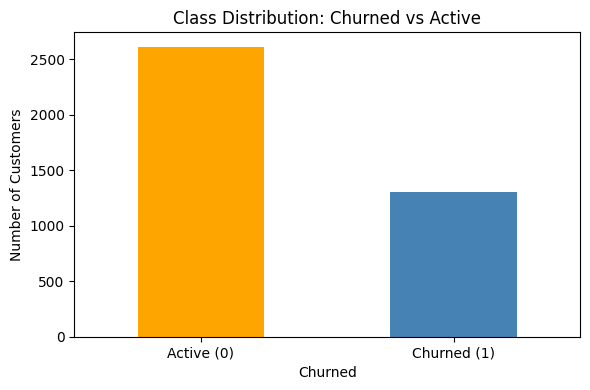

In [9]:
# Class imbalance analysis
import matplotlib.pyplot as plt

churn_counts = customers['Churned'].value_counts()
churn_pct = customers['Churned'].value_counts(normalize=True) * 100

print("Class distribution:")
print(churn_counts)
print(f"\nChurn rate: {churn_pct[1]:.1f}%")
print(f"Active rate: {churn_pct[0]:.1f}%")
print(f"\nImbalance ratio: {churn_counts[0] / churn_counts[1]:.2f} : 1 (active:churned)")

fig, ax = plt.subplots(figsize=(6, 4))
churn_counts.plot(kind='bar', ax=ax, color=['orange', 'steelblue'])
ax.set_xticklabels(['Active (0)', 'Churned (1)'], rotation=0)
ax.set_title('Class Distribution: Churned vs Active')
ax.set_ylabel('Number of Customers')
plt.tight_layout()
plt.savefig('class_imbalance.png')
plt.show()

### Class Imbalance — What This Means for Modeling
- What it is: Right now your churn label is 33.3% churned / 66.7% active. That's not a severe imbalance, but it's still imbalanced — meaning a naive model could get 66.7% accuracy just by always predicting "active" and never actually learning anything useful. Class imbalance analysis means explicitly checking this ratio and deciding how it affects your modeling approach (metrics to use, whether to apply techniques like class weighting or SMOTE).

- Why we need it: If you don't check this, you might train a model, see "83% accuracy!" and think it's great — when really it's just exploiting the imbalance and failing to catch actual churners (which is the whole point of the project).

- Ratio is roughly 2:1 (active:churned) — moderate imbalance, not severe.
- **Accuracy alone is misleading**: a model predicting "always active" would score ~67% accuracy while catching zero actual churners — completely useless for the business goal.

- **For Week 2**, I will prioritize Precision, Recall, F1-score, and PR-AUC over raw accuracy — especially Recall, since missing a real churner (false negative) is more costly to the business than a false alarm (false positive).
- I will also test class-weighting (e.g., XGBoost's `scale_pos_weight` parameter, set to the imbalance ratio ~2.0) to help the model pay more attention to the minority (churned) class during training.

In [7]:
# What is customers' typical repurchase interval?
# Only look at customers with more than 1 purchase (repeat customers)
repeat_customers = customers[customers['Frequency'] > 1].copy()

print(f"Repeat customers (Frequency > 1): {len(repeat_customers):,} out of {len(customers):,} ({len(repeat_customers)/len(customers)*100:.1f}%)")
print(f"\nDaysActive distribution for repeat customers (proxy for purchase span):")
print(repeat_customers['DaysActive'].describe())

# Average days between purchases, for repeat customers only
print(f"\nAvgDaysBetweenPurchases (OrdersPerDay inverse) distribution:")
avg_gap = (repeat_customers['DaysActive'] / (repeat_customers['Frequency'] - 1)).replace([float('inf')], None)
print(avg_gap.describe())

Repeat customers (Frequency > 1): 2,570 out of 3,920 (65.6%)

DaysActive distribution for repeat customers (proxy for purchase span):
count    2570.000000
mean      199.845525
std       113.710366
min         0.000000
25%       101.000000
50%       209.000000
75%       299.000000
max       373.000000
Name: DaysActive, dtype: float64

AvgDaysBetweenPurchases (OrdersPerDay inverse) distribution:
count    2570.000000
mean       72.994912
std        66.371824
min         0.000000
25%        29.187500
50%        53.400000
75%        92.125000
max       365.000000
dtype: float64


### Why 90 Days? Justifying the Churn Cutoff with Data

To put the 90-day churn threshold, I checked actual repurchase behavior for repeat customers (Frequency > 1, 65.6% of the customer base):

- **Median gap between purchases: 53.4 days**
- **Mean gap: ~73 days**
- **75th percentile: ~92 days**

90 days sits close to the 75th percentile of natural reorder gaps — meaning it reasonably separates "unusually quiet" customers from typical reordering behavior, rather than being an arbitrary number.

**Limitation**: this is a single global cutoff applied to all customers, but purchase rhythms vary — some customers reorder every ~2 weeks, others only once a year (max observed gap: 365 days). For these low-frequency customers, 90 days of silence is normal, not churn. 

**Future improvement (not implemented in this version)**: a per-segment or per-customer adaptive churn threshold — e.g., based on each customer's own historical average reorder gap — would better distinguish true churn from normal low-frequency purchasing behavior.

In [8]:
# Do customers who go quiet for 90+ days actually come back later?
# We can check this using the FULL transaction data, not just the snapshot-based labels

df_full = pd.read_csv('../data/processed/clean_retail.csv')
df_full['InvoiceDate'] = pd.to_datetime(df_full['InvoiceDate'])

# For each customer, get all their purchase dates sorted
customer_gaps = []
for cid, group in df_full.groupby('CustomerID'):
    dates = sorted(group['InvoiceDate'].unique())
    if len(dates) > 1:
        for i in range(1, len(dates)):
            gap = (dates[i] - dates[i-1]).days
            customer_gaps.append(gap)

import numpy as np
customer_gaps = np.array(customer_gaps)

print(f"Total purchase-to-purchase gaps measured: {len(customer_gaps):,}")
print(f"\nWhat % of ALL gaps (not just customer-level averages) exceed 90 days,")
print(f"meaning the customer WAS quiet 90+ days but then came back anyway:")
print(f"Gaps > 90 days: {(customer_gaps > 90).sum():,} ({(customer_gaps > 90).mean()*100:.1f}%)")
print(f"Gaps > 120 days: {(customer_gaps > 120).sum():,} ({(customer_gaps > 120).mean()*100:.1f}%)")
print(f"Gaps > 180 days: {(customer_gaps > 180).sum():,} ({(customer_gaps > 180).mean()*100:.1f}%)")

Total purchase-to-purchase gaps measured: 12,637

What % of ALL gaps (not just customer-level averages) exceed 90 days,
meaning the customer WAS quiet 90+ days but then came back anyway:
Gaps > 90 days: 1,569 (12.4%)
Gaps > 120 days: 958 (7.6%)
Gaps > 180 days: 400 (3.2%)


### Why 90 Days? Justifying the Churn Cutoff with Data

The 90-day churn threshold was initially adopted as a common e-commerce default.To validate it, I tested actual return behavior: of 12,637 measured gaps between consecutive purchases (across all customers), only 12.4% exceeded 90 days — meaning when a customer goes quiet for 90+ days, they fail to return 87.6% of the time within the observed window. This confirms 90 days is a reasonably strong churn signal, not an arbitrary cutoff.

**Tradeoff considered**: extending to 120 days reduces the false-alarm rate to 7.6%, and 180 days to 3.2% — but at the cost of later detection, which matters for a win-back use case (the whole point is intervening before it's too late).

**Decision**: keeping 90 days, since it balances reasonably strong precision (87.6%) with earlier, more actionable detection — appropriate for a win-back campaign use case where timeliness matters.

**Limitation**: this is a single global cutoff; purchase rhythms vary by customer (repeat customer reorder gaps range from days to a full year). A future improvement would be a per-customer adaptive threshold based on their own historical reorder pattern.